# `noise_module_lucid` — the LUCiD-customised front-end noise module

This notebook explains the package in `src/noise_module_lucid/`: what it adds to
a LUCiD water-Cherenkov simulation, why each term is there, and how to use it.
It is the Layer-2 companion to `noise_models_herald_lucid.ipynb`, focused on the
module rather than the two detectors side by side.

**The package is ours (MIT); it depends on `noise_module` and never forks it.**
LUCiD's own licence (gate A0) is separate and still open; nothing here imports
LUCiD at run time.

### Three layers, kept apart

| layer | owns | examples | enters `Sigma`? |
|---|---|---|---|
| signal / background physics | event generators (LUCiD, PhotonSim, ...) | DSNB, atmospheric tail, QE vs DIS, radon | no |
| LUCiD event stochastic layer | `lucid/simulation/digitizer.py` | dark counts, TTS, SPE charge, pre/after pulse | no |
| **front-end acquisition** | **`noise_module_lucid`** | amplifier floor + bandwidth, clock lines + coherence, cable delay, digitiser, alias fold | **yes** (and structural N) |

LUCiD emits a `(n_sensors, n_bins)` array of **photoelectrons per 1 ns bin** at
1 GHz. It models photon transport, quantum efficiency, SPE charge smearing,
transit-time spread, dark counts and TDC jitter — every one independent per
photon and per PMT, with **no electronic noise and no covariance between
channels anywhere**. That hole is what this package fills.

The sorted instruction list (what belongs here vs in LUCiD vs in the event
generators) is in `src/noise_module_lucid/docs/INSTRUCTION_SORTING_2026-09-24.md`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from scipy.signal import csd, welch

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "noise_module").is_dir())
sys.path.insert(0, str(REPO / "src"))

import noise_module_lucid as nml
from noise_module import NoiseGenerator, MultiChannelNoiseGenerator
from noise_module_lucid import digitiser, delay, pulses, interventions

PAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#9a9a95",
                     "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
                     "axes.titlecolor": "#0b0b0b", "lines.linewidth": 1.4, "font.size": 9})
FS_L, N_L = 1e9, 512
print("noise_module_lucid", nml.__version__, "| repo", REPO)

noise_module_lucid 0.2.0 | repo /Users/dowlingwong/Documents/VERITAS


## 1. The front-end preset

`PMT_FRONTEND_V2` is a **composite one-sided PSD** on LUCiD's grid (1 ns bins,
512 ns record → df = 1.95 MHz, Nyquist 500 MHz). It has five terms, split into a
**private** process (one per PMT) and a **shared** process (one per crate):

| term | origin | private / shared |
|---|---|---|
| amplifier floor | front-end transistor thermal + shot | private |
| flicker (1/f) | transistor 1/f | private |
| front-end bandwidth (250 MHz, order 2) | amplifier / cable low-pass | **transfer function on the floor** |
| base / connector ringing (150 MHz bump) | impedance mismatch | **transfer function on the floor** |
| clock 62.5 MHz + 2nd/3rd harmonics | ADC clock pickup | shared |

Two rules (V1 of the preset broke both; see
`src/noise_module_lucid/docs/LUCID_NOISE_REVIEW_2026-09-11.md`):

1. **A bandwidth is a filter, not a source.** The roll-off and the ringing
   *multiply* the white floor (`filtered`), they are not summed with it.
2. **Coherence belongs to a term, not to the crate.** The clock lines are the
   shared process; the floor and flicker are private.

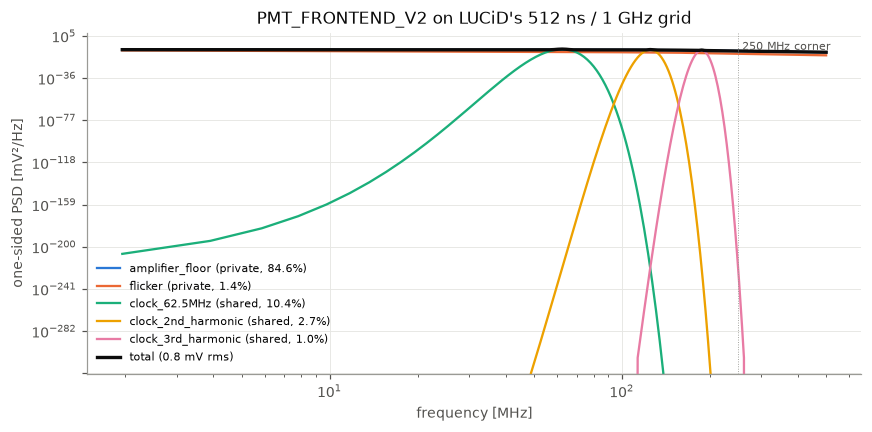

integral S df = 0.6400 mV² (target 0.6400000000000001)
S(500 MHz)/S(2 MHz) = 0.003  (V1 additive roll-off was 0.53)


In [2]:
N = N_L
f, S_total, meta = NoiseGenerator(nml.PMT_FRONTEND_V2, seed=0).build_psd_density(N, return_metadata=True)
df = FS_L / N
fM = f / 1e6
shares = {c["name"]: c["integrated_power_after_global_scaling"] / nml.RMS_MV**2
          for c in meta["component_contributions"]}

fig, ax = plt.subplots(figsize=(8, 4))
for i, c in enumerate(nml.PMT_FRONTEND_V2["components"]):
    _, s = NoiseGenerator({**nml.PMT_FRONTEND_V2, "composite_psd_scaling": "absolute",
                           "components": [c]}).build_psd_density(N)
    factor = nml.RMS_MV**2 / sum(x["integrated_power"] for x in meta["component_contributions"])
    kind = "shared" if c in nml.PMT_SHARED else "private"
    ax.loglog(fM[1:], s[1:] * factor, color=PAL[i], lw=1.5,
              label=f"{c['name']} ({kind}, {shares[c['name']]:.1%})")
ax.loglog(fM[1:], S_total[1:], color="#0b0b0b", lw=2.2, label=f"total ({nml.RMS_MV} mV rms)")
ax.axvline(250, color="#9a9a95", lw=0.6, ls=":"); ax.text(258, 3e-9, "250 MHz corner", fontsize=7, color="#52514e")
ax.set_xlabel("frequency [MHz]"); ax.set_ylabel("one-sided PSD [mV²/Hz]")
ax.set_title("PMT_FRONTEND_V2 on LUCiD's 512 ns / 1 GHz grid")
ax.legend(frameon=False, fontsize=7.5)
plt.tight_layout(); plt.show()
print(f"integral S df = {np.sum(S_total[1:]) * df:.4f} mV² (target {nml.RMS_MV**2})")
print(f"S(500 MHz)/S(2 MHz) = {S_total[-1] / S_total[1]:.3f}  (V1 additive roll-off was 0.53)")

## 2. The units bridge

LUCiD's bin holds photoelectrons, so a PSD in pe²/Hz means nothing physically.
`units.to_mv` convolves each PMT's histogram with a **single-photoelectron
voltage template** (2 ns rise, 8 ns fall, 4 mV per pe) — now the trace is in mV
and a PSD in mV²/Hz is meaningful.

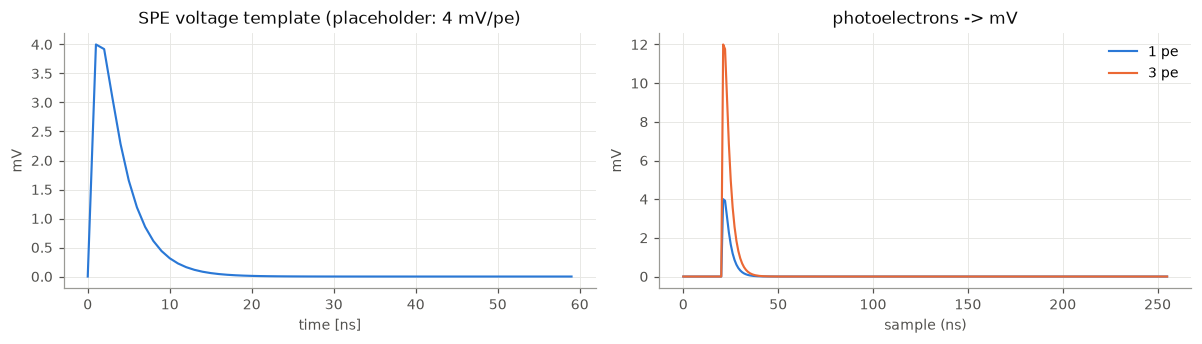

peak mV for 1 pe / 3 pe: 4.0 12.0


In [3]:
spe = nml.spe_template()
t_ns = np.arange(len(spe))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(t_ns, spe, color=PAL[0]); ax[0].set_xlabel("time [ns]"); ax[0].set_ylabel("mV")
ax[0].set_title("SPE voltage template (placeholder: 4 mV/pe)")
wf = np.zeros((2, 256)); wf[0, 20] = 1.0; wf[1, 20] = 3.0
mv = nml.to_mv(wf)
ax[1].plot(mv[0], color=PAL[0], label="1 pe"); ax[1].plot(mv[1], color=PAL[1], label="3 pe")
ax[1].set_xlabel("sample (ns)"); ax[1].set_ylabel("mV"); ax[1].set_title("photoelectrons -> mV"); ax[1].legend(frameon=False)
plt.tight_layout(); plt.show()
print("peak mV for 1 pe / 3 pe:", round(mv[0].max(), 2), round(mv[1].max(), 2))

## 3. Between channels: crates, and coherence as a function of frequency

Coherent pickup is **per front-end board**, not per detector: PMTs on one board
share the clock, not each other's amplifier thermal noise. `add_pmt_noise`
injects noise crate by crate, and the crate is built in the
`spectral_shared_private` mode, so the implied cross-spectral density is

$$S(f) = S_{\text{shared}}(f)\,gg^\top + S_{\text{private}}(f)\,\mathrm{diag}(p^2)$$

and the pairwise correlation $\rho_{ij}(f)$ is ≈ 1 at the clock line and ≈ 0 on
the floor. This is what makes the LUCiD $\Sigma$ deliberately **not
Kronecker-separable**.

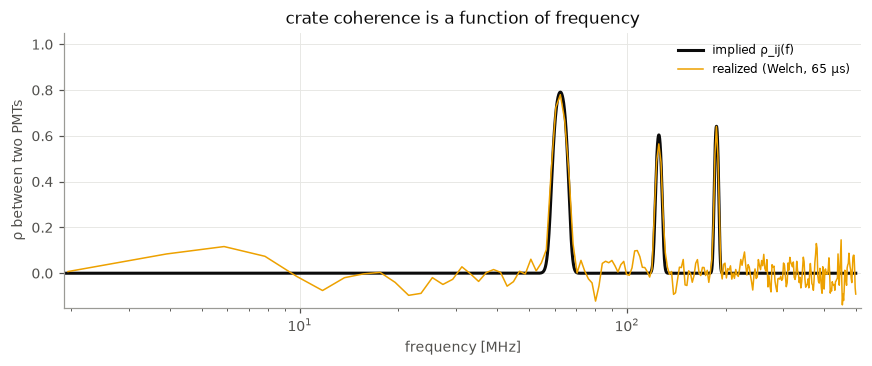

implied ρ at 62.5 MHz: 0.791


In [4]:
base, crate = nml.crate_preset()
gen = MultiChannelNoiseGenerator(base, {**crate, "n_channels": 2,
                                        "channel_gain_jitter": 0.0, "private_strength_range": [1.0, 1.0]}, seed=7)
X2, m2 = gen.generate(1 << 16, return_metadata=True)
f_rho, rho_implied = MultiChannelNoiseGenerator.implied_correlation_spectrum(m2, 0, 1)
fw, s01 = csd(X2[0], X2[1], fs=FS_L, nperseg=N_L)
_, s00 = welch(X2[0], fs=FS_L, nperseg=N_L); _, s11 = welch(X2[1], fs=FS_L, nperseg=N_L)
rho_real = np.real(s01) / np.sqrt(s00 * s11)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.semilogx(f_rho[1:] / 1e6, rho_implied[1:], color="#0b0b0b", lw=2.0, label="implied ρ_ij(f)")
ax.semilogx(fw[1:] / 1e6, rho_real[1:], color=PAL[3], lw=1.0, label="realized (Welch, 65 µs)")
ax.set_xlim(1.9, 520); ax.set_ylim(-0.15, 1.05); ax.set_xlabel("frequency [MHz]"); ax.set_ylabel("ρ between two PMTs")
ax.set_title("crate coherence is a function of frequency"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()
print("implied ρ at 62.5 MHz:", round(float(np.interp(6.25e7, f_rho, rho_implied)), 3))

## 4. The new front-end modules

Three instruction-list items are genuinely new front-end work (the rest are
signal/background physics or LUCiD's own event layer):

| module | what it models | contract |
|---|---|---|
| `delay.py` | cable length → a lagged signal (`H = exp(-2πi f τ)`) | structural N |
| `digitiser.py` | ADC quantisation (LSB²/12) and sampling / aperture jitter | structural N |
| `pulses.py` | dark counts, pre-pulses, after-pulses (event-level, injectable) | N if the rate shifts |

A cable delay is **phase-only**, so it cannot be a PSD component: every
`noise_module` spectral primitive multiplies the *density* by `|H|²`, and
`|exp(-2πi f τ)|² = 1`. It is applied to the trace on the signal path.

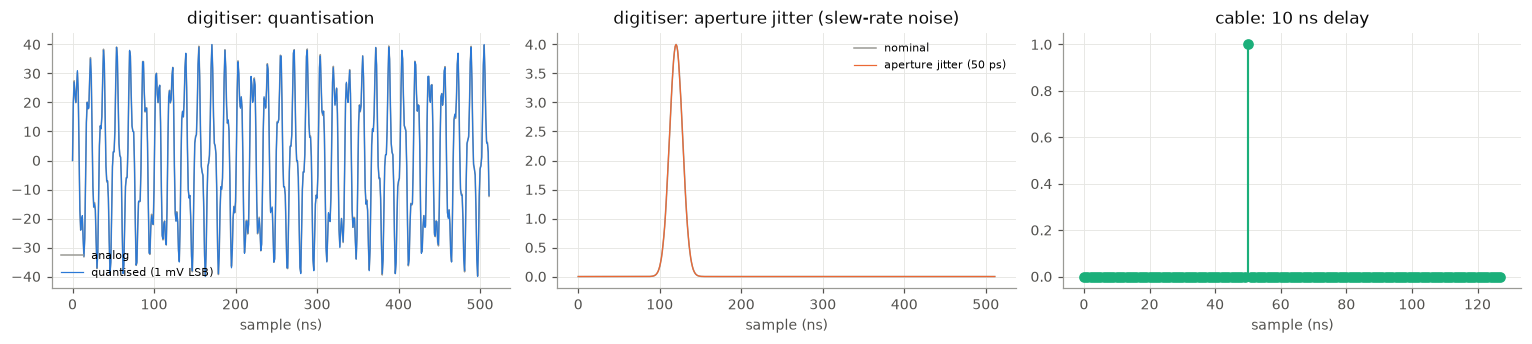

quantisation variance: 0.0872 | theory LSB²/12 = 0.0833
jitter added rms: 0.0026 mV | model: first_order_derivative
a flat signal is untouched by jitter: True


In [5]:
rng = np.random.default_rng(0)
t = np.arange(512)
# incommensurate tones so the fractional part is ~uniform over the LSB -> LSB^2/12
sine = (30.0 * np.sin(2 * np.pi * t / 16.7) + 10.0 * np.sin(2 * np.pi * t / 5.3))[None, :]
pulse = (4.0 * np.exp(-0.5 * ((t - 120) / 8.0) ** 2))[None, :]   # a fast edge for jitter
xq, qmeta = digitiser.quantise(sine, lsb=1.0, return_metadata=True)
xj, jmeta = digitiser.aperture_jitter_noise(pulse, 50e-12, FS_L, np.random.default_rng(1), return_metadata=True)
imp = np.zeros((1, 128)); imp[0, 40] = 1.0

fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))
ax[0].plot(sine[0], color="#9a9a95", lw=1.0, label="analog"); ax[0].plot(xq[0], color=PAL[0], lw=0.8, label="quantised (1 mV LSB)")
ax[0].set_title("digitiser: quantisation"); ax[0].legend(frameon=False, fontsize=7); ax[0].set_xlabel("sample (ns)")
ax[1].plot(pulse[0], color="#9a9a95", lw=1.0, label="nominal"); ax[1].plot(xj[0], color=PAL[1], lw=0.8, label="aperture jitter (50 ps)")
ax[1].set_title("digitiser: aperture jitter (slew-rate noise)"); ax[1].legend(frameon=False, fontsize=7); ax[1].set_xlabel("sample (ns)")
ax[2].stem(np.arange(128), delay.cable_delay(imp, 10.0 / FS_L, FS_L)[0], basefmt=" ", linefmt=PAL[2], markerfmt="o")
ax[2].set_title("cable: 10 ns delay"); ax[2].set_xlabel("sample (ns)")
plt.tight_layout(); plt.show()
print("quantisation variance:", round((xq - sine).var(), 4), "| theory LSB²/12 =", round(qmeta["noise_variance"], 4))
print("jitter added rms:", round(jmeta["added_rms"], 4), "mV | model:", jmeta["model"])
print("a flat signal is untouched by jitter:", np.allclose(digitiser.aperture_jitter_noise(np.ones((1, 64)), 1e-11, FS_L, rng), 1.0))

dark counts per channel: [7, 13] | after-pulse counts: [2, 1]


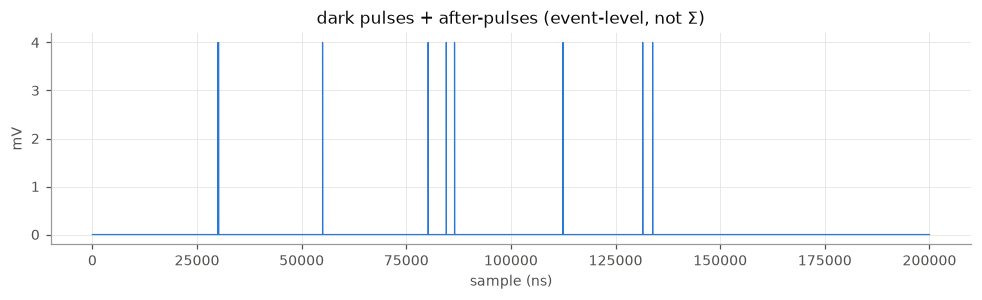

In [6]:
# Event-level processes: kept out of Sigma, but declared and injectable.
tr = np.zeros((2, 200_000))                       # 200 us so the dark rate resolves
prim = [np.array([30_000.0, 80_000.0]), np.array([50_000.0])]
tr, dark = pulses.add_dark_pulses(tr, FS_L, rate_hz=50_000.0, rng=np.random.default_rng(2), return_metadata=True)
tr, ap = pulses.add_afterpulses(tr, FS_L, prim, probability=1.0, tau_s=100e-9, rng=np.random.default_rng(3),
                                return_metadata=True)
print("dark counts per channel:", dark["counts_per_channel"], "| after-pulse counts:", ap["counts_per_channel"])
plt.figure(figsize=(9, 2.8)); plt.plot(tr[0], color=PAL[0], lw=0.8)
plt.xlabel("sample (ns)"); plt.ylabel("mV"); plt.title("dark pulses + after-pulses (event-level, not Σ)")
plt.tight_layout(); plt.show()

## 5. Declared interventions (the N families)

`interventions.py` names the acquisition-contract changes. *Preset*
interventions return a `(base, crate)` pair (a changed covariance); *trace*
interventions transform a generated mV trace (a structural change).

- `clock_x5` / `broadband_common_mode_30` — preset
- `quantise_1mV`, `aperture_jitter_50ps`, `cable_delay_10ns`, `alias_fold_4` — trace

interventions: {'clock_x2': 'preset', 'clock_x5': 'preset', 'clock_deterministic': 'preset', 'broadband_common_mode_30': 'preset', 'quantise_1mV': 'trace', 'aperture_jitter_50ps': 'trace', 'cable_delay_10ns': 'trace', 'cable_dispersive_10ns': 'trace', 'alias_fold_4': 'trace'}


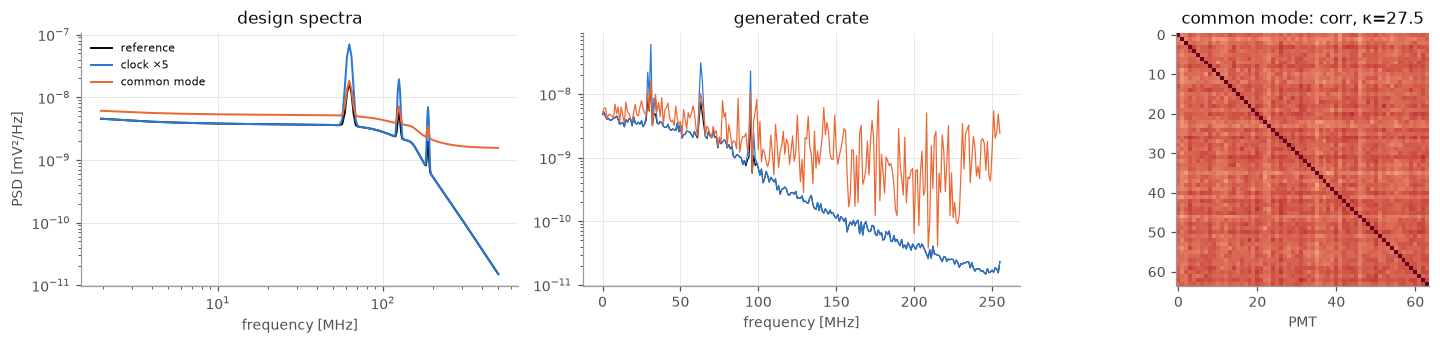

deterministic clock total power: 0.09 mV²
dark target/baseline/injected [Hz]: 5000.0 4200.0 800.0


In [7]:
print("interventions:", interventions.describe())

fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))
for label, preset, col in [("reference", None, "#0b0b0b"),
                           ("clock ×5", interventions.clock_amplitude(5.0), PAL[0]),
                           ("common mode", interventions.broadband_common_mode(0.43), PAL[1])]:
    b, c = nml.crate_preset() if preset is None else preset
    g = MultiChannelNoiseGenerator(b, {**c, "n_channels": 64}, seed=1)
    Xc, mc = g.generate(N_L, return_metadata=True)
    _, Sc = NoiseGenerator(b, seed=0).build_psd_density(N_L)
    ax[0].loglog(fM[1:], Sc[1:], color=col, lw=1.3, label=label)
    ax[1].semilogy(np.mean(np.abs(rfft(Xc, axis=-1))**2, axis=0)[1:] * 2 / (FS_L * N_L), color=col, lw=0.8)
    ax[2].imshow(np.corrcoef(Xc), vmin=-1, vmax=1, cmap="RdBu_r"); ax[2].grid(False); ax[2].set_title(f"{label}: corr, κ={nml.kappa(mc):.1f}")
ax[0].set_xlabel("frequency [MHz]"); ax[0].set_ylabel("PSD [mV²/Hz]"); ax[0].set_title("design spectra"); ax[0].legend(frameon=False, fontsize=7)
ax[1].set_xlabel("frequency [MHz]"); ax[1].set_title("generated crate"); ax[2].set_xlabel("PMT")
plt.tight_layout(); plt.show()

# deterministic clock: same PSD, real non-Gaussianity (P1.2)
xd, md = nml.add_pmt_noise(np.zeros((64, N_L)), interventions.deterministic_clock(), seed=1)
print("deterministic clock total power:", round(md[0]["deterministic_clock"]["total_power"], 4), "mV²")

# dark-noise contract (P0.2): rate_hz is the target total, the baseline is subtracted
_, dm = nml.add_dark_pulses(np.zeros((4, 10_000)), FS_L, 5_000.0, rng=np.random.default_rng(2), return_metadata=True)
print("dark target/baseline/injected [Hz]:", dm["target_rate_hz"], dm["baseline_rate_hz"], dm["injected_rate_hz"])

## 6. The κ floor: why covariance cells need a longer window

On a **matched cell** (assumed Σ̂ = realized Σ by construction) every measured
κ(Σ̂⁻¹Σ) above 1.0 is estimator noise. The floor is set by N/C: with 64 channels
and a 512 ns record, N/C = 8 and the floor is ~6.7 — the estimator cannot see a
real mismatch under its own noise. The covariance cells must use a 16–32 µs
window (or a smaller crate).

In [8]:
# SPE / front-end bandwidth consistency (P0.3)
print("bandwidth report:", {k: round(v, 3) for k, v in nml.bandwidth_report().items()})
rows = []
for Nwin in (512, 4096, 32768, 65536):
    rows.append((Nwin, Nwin / 64, nml.matched_cell_kappa_floor(Nwin, C=64)))
for Nwin, nc, k in rows:
    print(f"N = {Nwin:6d}  ({Nwin / FS_L * 1e9:8.2f} ns)  N/C = {nc:6.1f}  κ floor = {k:.2f}")

bandwidth report: {'signal_f3db_hz': 50945281.982, 'noise_corner_hz': 127363204.956, 'bandwidth_ratio': 2.5, 'noise_above_3x_signal_fraction': 0.137, 'total_power': 0.64}
N =    512  (  512.00 ns)  N/C =    8.0  κ floor = 13.80
N =   4096  ( 4096.00 ns)  N/C =   64.0  κ floor = 2.46
N =  32768  (32768.00 ns)  N/C =  512.0  κ floor = 1.37
N =  65536  (65536.00 ns)  N/C = 1024.0  κ floor = 1.28


## What to take away

- The package adds exactly the **front end** LUCiD does not simulate: amplifier
  floor + bandwidth, clock lines with frequency-dependent crate coherence,
  cable delay, digitiser, alias fold.
- It **depends on `noise_module`** for the spectral grammar, the multichannel
  generator and the resampling; it never forks it (see
  `src/noise_module_lucid/README.md`).
- Dark counts, pre/after pulses and pile-up are **event-level**, kept out of Σ.
  DSNB, the atmospheric tail, QE vs DIS and radon are **signal/background
  physics** and belong to the event generators.
- Every level is a placeholder (`nml.PROVENANCE`): 0.8 mV rms, 4 mV/pe,
  SPE 1 ns/3 ns, 62.5 MHz clock, 64 PMTs/crate. The front-end corner is now
  **derived** from the SPE bandwidth (2.5x, ~127 MHz), so the noise band is
  matched to the signal band. Do not quote it as a validated detector model
  before calibration.
- The covariance cells need a **16–32 µs** window: at 512 ns the matched-cell κ
  floor is ~6.7 and the alarm would read estimator noise.